# Unified Climate Forecasting: Temperature & ET0

This notebook implements a unified forecasting system for both **temperature** and **ET0 (evapotranspiration)**.

**Models:**
- SARIMA (Seasonal ARIMA)
- LSTM (Long Short-Term Memory)
- Linear Regression (Baseline)

**✨ Google Colab Compatible** - Data automatically downloaded from Drive

**Benefits of unified approach:**
1. Single source of truth
2. Easy comparison between variables
3. Consistent methodology
4. Better maintainability

## 🔧 Environment Setup (Colab Compatible)

In [4]:
# Detect environment (Colab or Local)
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("🌐 Running in Google Colab")
    print("📥 Installing required packages...")
    !pip install -q pmdarima statsmodels
    print("✅ Packages installed!")
else:
    print("💻 Running locally")

🌐 Running in Google Colab
📥 Installing required packages...
✅ Packages installed!


## 📥 Data Download (Automatic from Google Drive)

In [5]:
import os

if IN_COLAB:
    # Download data from Google Drive
    print("📥 Downloading data from Google Drive...")

    # Extract file ID from share link
    file_id = "1TnlYsNUJq7--Kgj9AWGmhMAiW1N4ExbW"

    # Download using gdown
    !pip install -q gdown
    import gdown

    url = f"https://drive.google.com/uc?id={file_id}"
    output = "algiers_monthly_processed_v2.csv"
    gdown.download(url, output, quiet=False)

    data_path = output
    print(f"✅ Data downloaded to: {data_path}")

    # Create output directories
    os.makedirs('Results', exist_ok=True)
    os.makedirs('Predictions', exist_ok=True)
    print("✅ Output directories created")

else:
    # Local path
    from pathlib import Path
    data_path = Path('../Preprocessed_dataset/algiers_monthly_processed_v2.csv')
    print(f"💻 Using local data: {data_path}")

📥 Downloading data from Google Drive...


Downloading...
From: https://drive.google.com/uc?id=1TnlYsNUJq7--Kgj9AWGmhMAiW1N4ExbW
To: /content/algiers_monthly_processed_v2.csv
100%|██████████| 60.8k/60.8k [00:00<00:00, 56.2MB/s]

✅ Data downloaded to: algiers_monthly_processed_v2.csv
✅ Output directories created


## 1. Library Imports

In [6]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Time series models
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima

# Deep learning
try:
    from tensorflow import keras
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    from sklearn.preprocessing import MinMaxScaler
    LSTM_AVAILABLE = True
    print("✅ TensorFlow available - LSTM enabled")
except ImportError:
    LSTM_AVAILABLE = False
    print("⚠️ TensorFlow not available - LSTM will be skipped")

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import linregress

# Plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("✅ Libraries imported successfully")

✅ TensorFlow available - LSTM enabled
✅ Libraries imported successfully


## 2. Load Data

In [7]:
# Load preprocessed data
df = pd.read_csv(data_path)
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

print(f"✅ Loaded {len(df)} months of data")
print(f"   Date range: {df.index.min()} to {df.index.max()}")
print(f"\nColumns: {list(df.columns)}")
df.head()

✅ Loaded 260 months of data
   Date range: 2002-01-01 00:00:00 to 2023-08-01 00:00:00

Columns: ['temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min', 'precipitation_sum', 'et0_fao_evapotranspiration', 'shortwave_radiation_sum', 'windspeed_10m_max', 'temp_anomaly', 'water_balance', 'cumulative_water_balance', 'aridity_index', 'temp_rolling_12m', 'precip_rolling_12m', 'SPI_12_z', 'SPEI_12_z']


,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,et0_fao_evapotranspiration,shortwave_radiation_sum,windspeed_10m_max,temp_anomaly,water_balance,cumulative_water_balance,aridity_index,temp_rolling_12m,precip_rolling_12m,SPI_12_z,SPEI_12_z
date,,,,,,,,,,,,,,,
2002-01-01,9.935484,15.038710,6.025806,46.0,49.58,321.59,14.564516,-7.542253,-3.58,-3.58,1.075488,NaN,NaN,NaN,NaN
2002-02-01,11.146429,16.353571,6.753571,12.3,64.85,395.78,16.396429,-6.331308,-52.55,-56.13,5.229839,NaN,NaN,NaN,NaN
2002-03-01,13.435484,18.400000,9.148387,39.3,98.36,570.91,21.129032,-4.042253,-59.06,-115.19,2.496447,NaN,NaN,NaN,NaN
2002-04-01,14.866667,19.743333,10.046667,28.2,118.59,689.53,19.910000,-2.611070,-90.39,-205.58,4.190459,NaN,NaN,NaN,NaN
2002-05-01,18.858065,24.351613,13.329032,23.4,162.17,811.72,22.148387,1.380328,-138.77,-344.35,6.900851,NaN,NaN,NaN,NaN


In [8]:
# Configuration
VARIABLES = {
    'temperature': {
        'column': 'temperature_2m_mean',
        'label': 'Temperature (°C)',
        'color': '#E74C3C'
    },
    'et0': {
        'column': 'et0_fao_evapotranspiration',
        'label': 'ET0 (mm/day)',
        'color': '#3498DB'
    }
}

FORECAST_END = '2040-12-01'
HISTORICAL_END = df.index.max()

# Configure output paths
if IN_COLAB:
    RESULTS_DIR = 'Results'
    PREDICTIONS_DIR = 'Predictions'
else:
    from pathlib import Path
    RESULTS_DIR = '../Results'
    PREDICTIONS_DIR = '../Predictions'

print(f"Forecasting for both variables until: {FORECAST_END}")

Forecasting for both variables until: 2040-12-01


## 3. Exploratory Data Analysis

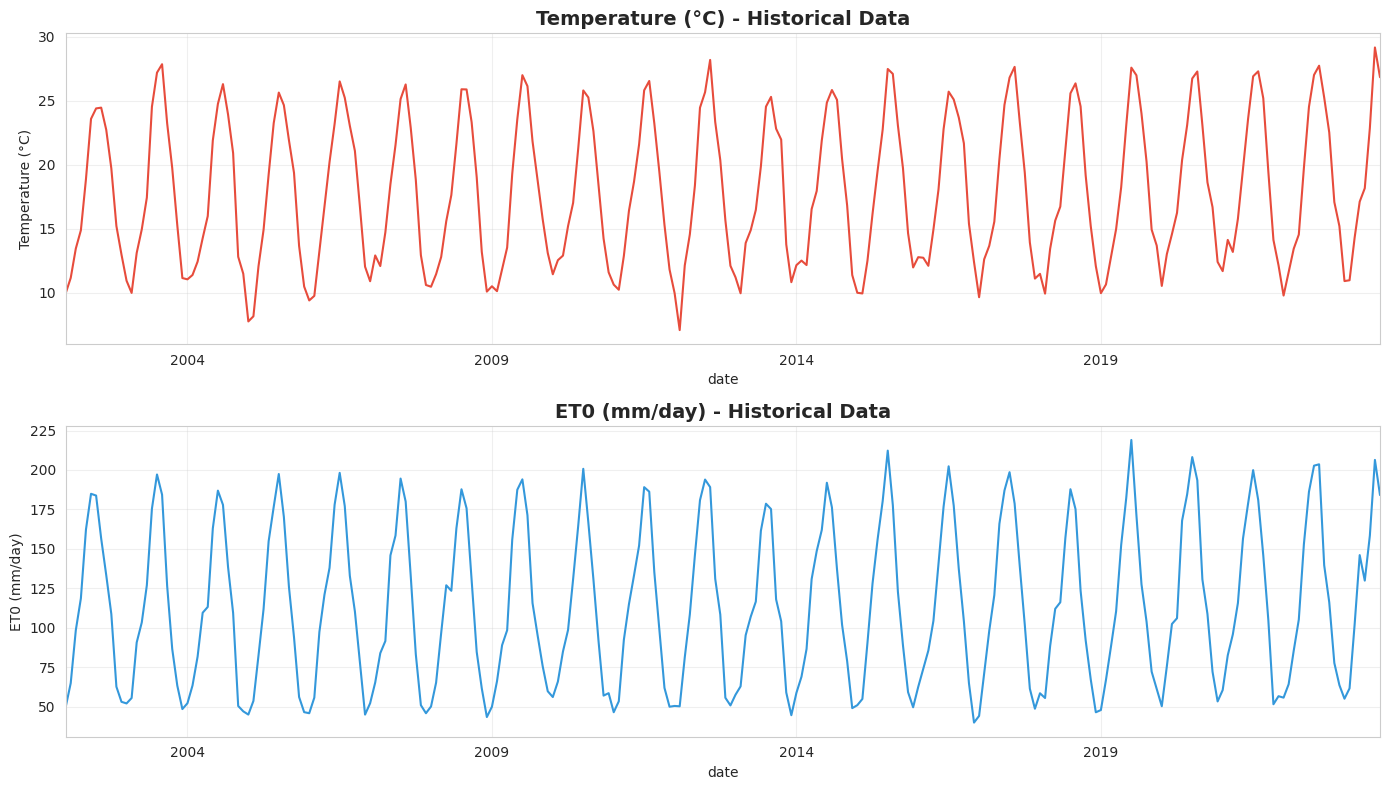

✅ Historical data visualization saved


In [9]:
# Visualize both variables
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for idx, (var_name, var_config) in enumerate(VARIABLES.items()):
    col = var_config['column']
    df[col].plot(ax=axes[idx], color=var_config['color'], linewidth=1.5)
    axes[idx].set_title(f"{var_config['label']} - Historical Data", fontsize=14, fontweight='bold')
    axes[idx].set_ylabel(var_config['label'])
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/historical_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Historical data visualization saved")

In [10]:
# Statistics summary
print("📊 **Statistical Summary**\n")
for var_name, var_config in VARIABLES.items():
    col = var_config['column']
    print(f"**{var_config['label']}**")
    print(df[col].describe())
    print()


📊 **Statistical Summary**

**Temperature (°C)**
count    260.000000
mean      17.826344
std        5.733771
min        7.065517
25%       12.753560
50%       16.754731
75%       23.113333
max       29.154839
Name: temperature_2m_mean, dtype: float64

**ET0 (mm/day)**
count    260.000000
mean     113.339000
std       50.497179
min       39.830000
25%       63.522500
50%      106.495000
75%      158.360000
max      219.020000
Name: et0_fao_evapotranspiration, dtype: float64



## 4. Model 1: SARIMA Forecasting

In [11]:
def forecast_sarima(data, variable_name, variable_config, forecast_end=FORECAST_END):
    """
    SARIMA forecast for a single variable
    """
    col = variable_config['column']
    ts = data[col].copy()

    print(f"\n{'='*60}")
    print(f"SARIMA Forecasting: {variable_config['label']}")
    print(f"{'='*60}")

    # Auto ARIMA to find best parameters
    print("🔍 Finding optimal SARIMA parameters...")
    model_auto = auto_arima(
        ts,
        seasonal=True,
        m=12,  # Monthly seasonality
        start_p=0, start_q=0,
        max_p=3, max_q=3,
        start_P=0, start_Q=0,
        max_P=2, max_Q=2,
        trace=False,
        suppress_warnings=True,
        stepwise=True
    )

    order = model_auto.order
    seasonal_order = model_auto.seasonal_order
    print(f"✅ Best SARIMA{order}x{seasonal_order}[12]")

    # Fit final model
    model = SARIMAX(
        ts,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    results = model.fit(disp=False)

    # Generate forecast
    forecast_steps = pd.date_range(
        start=ts.index[-1] + pd.DateOffset(months=1),
        end=forecast_end,
        freq='MS'
    )

    forecast = results.get_forecast(steps=len(forecast_steps))
    forecast_values = forecast.predicted_mean
    forecast_ci = forecast.conf_int(alpha=0.05)  # 95% CI

    # Create forecast dataframe
    forecast_df = pd.DataFrame({
        'date': forecast_steps,
        'forecast': forecast_values.values,
        'lower_bound': forecast_ci.iloc[:, 0].values,
        'upper_bound': forecast_ci.iloc[:, 1].values
    })

    print(f"✅ Forecast generated: {len(forecast_df)} months")

    return {
        'model': results,
        'forecast': forecast_df,
        'order': order,
        'seasonal_order': seasonal_order
    }

# Run SARIMA for both variables
sarima_results = {}
for var_name, var_config in VARIABLES.items():
    sarima_results[var_name] = forecast_sarima(df, var_name, var_config)


SARIMA Forecasting: Temperature (°C)
🔍 Finding optimal SARIMA parameters...
✅ Best SARIMA(1, 0, 0)x(1, 0, 1, 12)[12]
✅ Forecast generated: 208 months

SARIMA Forecasting: ET0 (mm/day)
🔍 Finding optimal SARIMA parameters...
✅ Best SARIMA(0, 0, 1)x(2, 0, 0, 12)[12]
✅ Forecast generated: 208 months


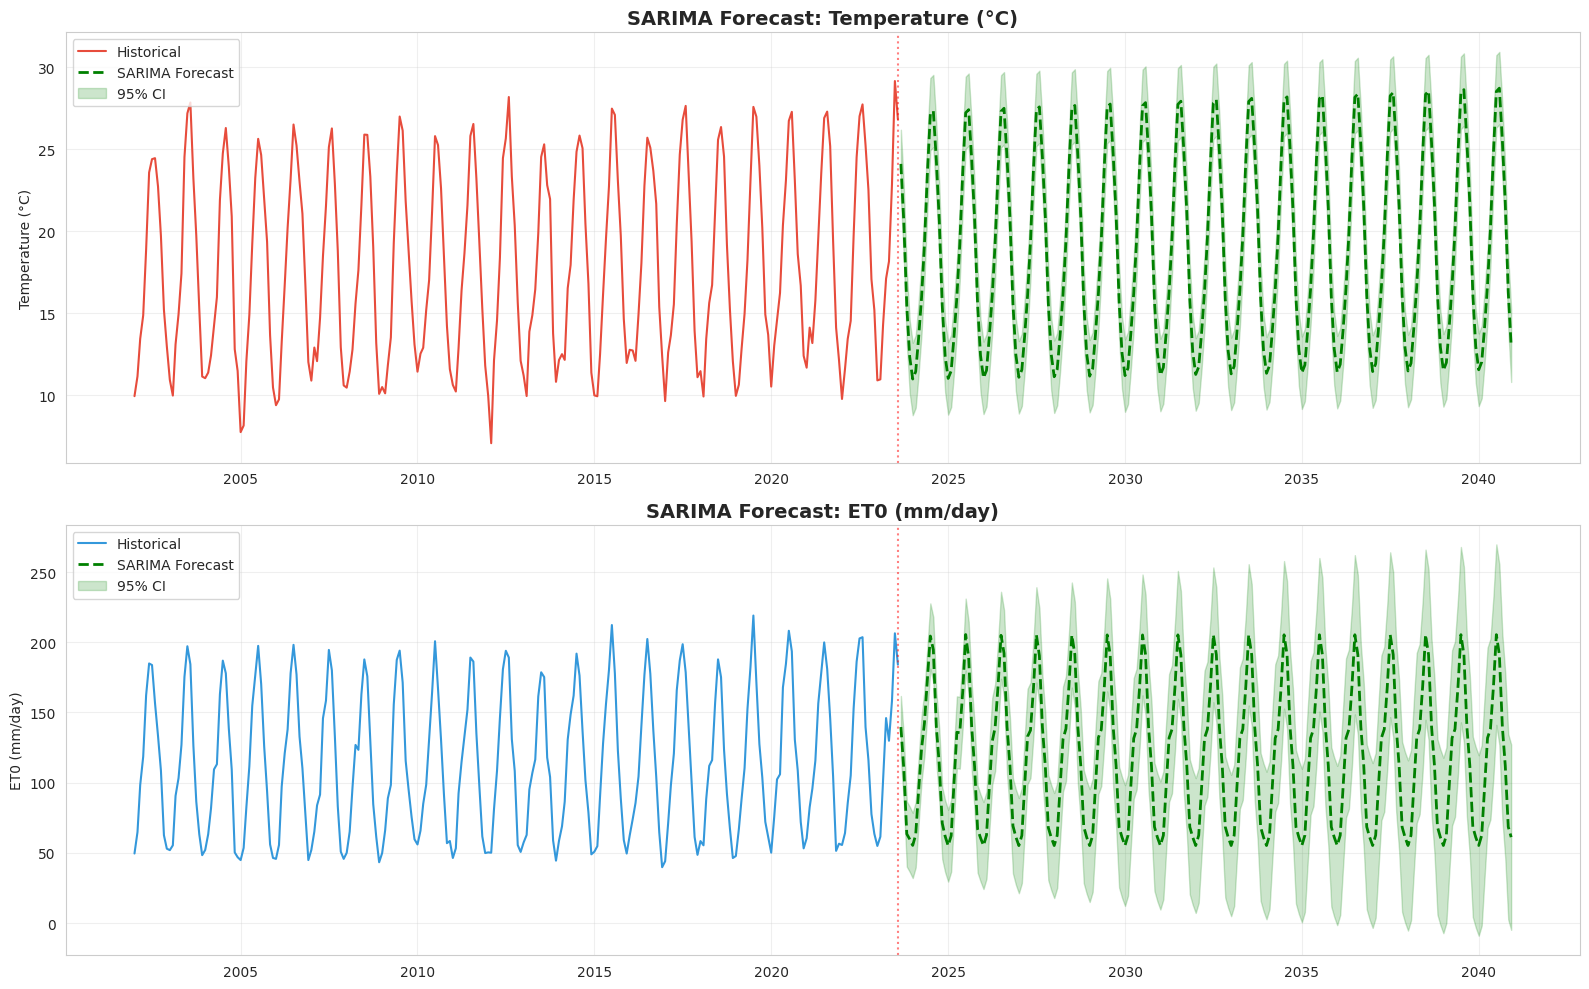

✅ SARIMA visualizations saved


In [12]:
# Visualize SARIMA forecasts
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

for idx, (var_name, var_config) in enumerate(VARIABLES.items()):
    col = var_config['column']
    forecast_df = sarima_results[var_name]['forecast']

    # Historical data
    axes[idx].plot(df.index, df[col],
                   label='Historical', color=var_config['color'], linewidth=1.5)

    # Forecast
    axes[idx].plot(forecast_df['date'], forecast_df['forecast'],
                   label='SARIMA Forecast', color='green', linewidth=2, linestyle='--')

    # Confidence interval
    axes[idx].fill_between(forecast_df['date'],
                           forecast_df['lower_bound'],
                           forecast_df['upper_bound'],
                           alpha=0.2, color='green', label='95% CI')

    axes[idx].set_title(f"SARIMA Forecast: {var_config['label']}",
                       fontsize=14, fontweight='bold')
    axes[idx].set_ylabel(var_config['label'])
    axes[idx].legend(loc='upper left')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].axvline(x=df.index[-1], color='red', linestyle=':', alpha=0.5, label='Forecast Start')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/sarima_unified_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ SARIMA visualizations saved")

## 5. Model 2: LSTM Forecasting (Optional - GPU Recommended)

In [13]:
# Check GPU availability (Colab)
if IN_COLAB and LSTM_AVAILABLE:
    import tensorflow as tf
    gpu_devices = tf.config.list_physical_devices('GPU')
    if gpu_devices:
        print(f"✅ GPU detected: {gpu_devices}")
        print("🚀 LSTM will use GPU acceleration")
    else:
        print("⚠️ No GPU detected - LSTM will run on CPU (slower)")
elif LSTM_AVAILABLE:
    print("💻 Running on local hardware")

✅ GPU detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
🚀 LSTM will use GPU acceleration


In [14]:
if LSTM_AVAILABLE:
    def prepare_lstm_data(data, column, lookback=12):
        """
        Prepare sequences for LSTM training
        """
        values = data[column].values.reshape(-1, 1)

        # Scale data
        scaler = MinMaxScaler(feature_range=(0, 1))
        scaled = scaler.fit_transform(values)

        # Create sequences
        X, y = [], []
        for i in range(lookback, len(scaled)):
            X.append(scaled[i-lookback:i, 0])
            y.append(scaled[i, 0])

        return np.array(X), np.array(y), scaler

    def build_lstm_model(lookback):
        """
        Build LSTM architecture
        """
        model = Sequential([
            LSTM(50, return_sequences=True, input_shape=(lookback, 1)),
            Dropout(0.2),
            LSTM(50, return_sequences=False),
            Dropout(0.2),
            Dense(25),
            Dense(1)
        ])

        model.compile(optimizer='adam', loss='mse')
        return model

    def forecast_lstm(data, variable_name, variable_config, forecast_end=FORECAST_END, lookback=12):
        """
        LSTM forecast for a single variable
        """
        col = variable_config['column']

        print(f"\n{'='*60}")
        print(f"LSTM Forecasting: {variable_config['label']}")
        print(f"{'='*60}")

        # Prepare data
        X, y, scaler = prepare_lstm_data(data, col, lookback)
        X = X.reshape((X.shape[0], X.shape[1], 1))

        print(f"Training samples: {len(X)}")

        # Build and train model
        model = build_lstm_model(lookback)
        print("🔧 Training LSTM model...")

        history = model.fit(
            X, y,
            epochs=50,
            batch_size=32,
            validation_split=0.1,
            verbose=0
        )

        print(f"✅ Training complete. Final loss: {history.history['loss'][-1]:.4f}")

        # Generate forecast
        forecast_steps = pd.date_range(
            start=data.index[-1] + pd.DateOffset(months=1),
            end=forecast_end,
            freq='MS'
        )

        # Iterative forecasting
        last_sequence = data[col].values[-lookback:].reshape(-1, 1)
        last_sequence_scaled = scaler.transform(last_sequence)

        predictions = []
        current_sequence = last_sequence_scaled.copy()

        for _ in range(len(forecast_steps)):
            input_seq = current_sequence.reshape(1, lookback, 1)
            pred_scaled = model.predict(input_seq, verbose=0)[0, 0]
            predictions.append(pred_scaled)

            # Update sequence
            current_sequence = np.append(current_sequence[1:], [[pred_scaled]], axis=0)

        # Inverse transform
        predictions = scaler.inverse_transform(np.array(predictions).reshape(-1, 1)).flatten()

        forecast_df = pd.DataFrame({
            'date': forecast_steps,
            'forecast': predictions
        })

        print(f"✅ Forecast generated: {len(forecast_df)} months")

        return {
            'model': model,
            'forecast': forecast_df,
            'scaler': scaler,
            'history': history
        }

    # Run LSTM for both variables
    lstm_results = {}
    for var_name, var_config in VARIABLES.items():
        lstm_results[var_name] = forecast_lstm(df, var_name, var_config)
else:
    print("⚠️ Skipping LSTM - TensorFlow not available")
    lstm_results = None


LSTM Forecasting: Temperature (°C)
Training samples: 248
🔧 Training LSTM model...
✅ Training complete. Final loss: 0.0066
✅ Forecast generated: 208 months

LSTM Forecasting: ET0 (mm/day)
Training samples: 248
🔧 Training LSTM model...
✅ Training complete. Final loss: 0.0065
✅ Forecast generated: 208 months


## 6. Model 3: Linear Regression (Baseline)

In [15]:
def forecast_linear(data, variable_name, variable_config, forecast_end=FORECAST_END):
    """
    Simple linear regression forecast
    """
    col = variable_config['column']

    print(f"\n{'='*60}")
    print(f"Linear Regression: {variable_config['label']}")
    print(f"{'='*60}")

    # Prepare time index
    x = np.arange(len(data))
    y = data[col].values

    # Fit linear regression
    slope, intercept, r_value, p_value, std_err = linregress(x, y)

    print(f"Slope: {slope:.4f}")
    print(f"R²: {r_value**2:.4f}")
    print(f"P-value: {p_value:.6f}")

    # Generate forecast
    forecast_steps = pd.date_range(
        start=data.index[-1] + pd.DateOffset(months=1),
        end=forecast_end,
        freq='MS'
    )

    start_idx = len(data)
    forecast_x = np.arange(start_idx, start_idx + len(forecast_steps))
    forecast_y = slope * forecast_x + intercept

    forecast_df = pd.DataFrame({
        'date': forecast_steps,
        'forecast': forecast_y
    })

    print(f"✅ Forecast generated: {len(forecast_df)} months")

    return {
        'slope': slope,
        'intercept': intercept,
        'r2': r_value**2,
        'forecast': forecast_df
    }

# Run Linear for both variables
linear_results = {}
for var_name, var_config in VARIABLES.items():
    linear_results[var_name] = forecast_linear(df, var_name, var_config)


Linear Regression: Temperature (°C)
Slope: 0.0066
R²: 0.0074
P-value: 0.166333
✅ Forecast generated: 208 months

Linear Regression: ET0 (mm/day)
Slope: 0.0494
R²: 0.0054
P-value: 0.237462
✅ Forecast generated: 208 months


## 7. Unified Comparison

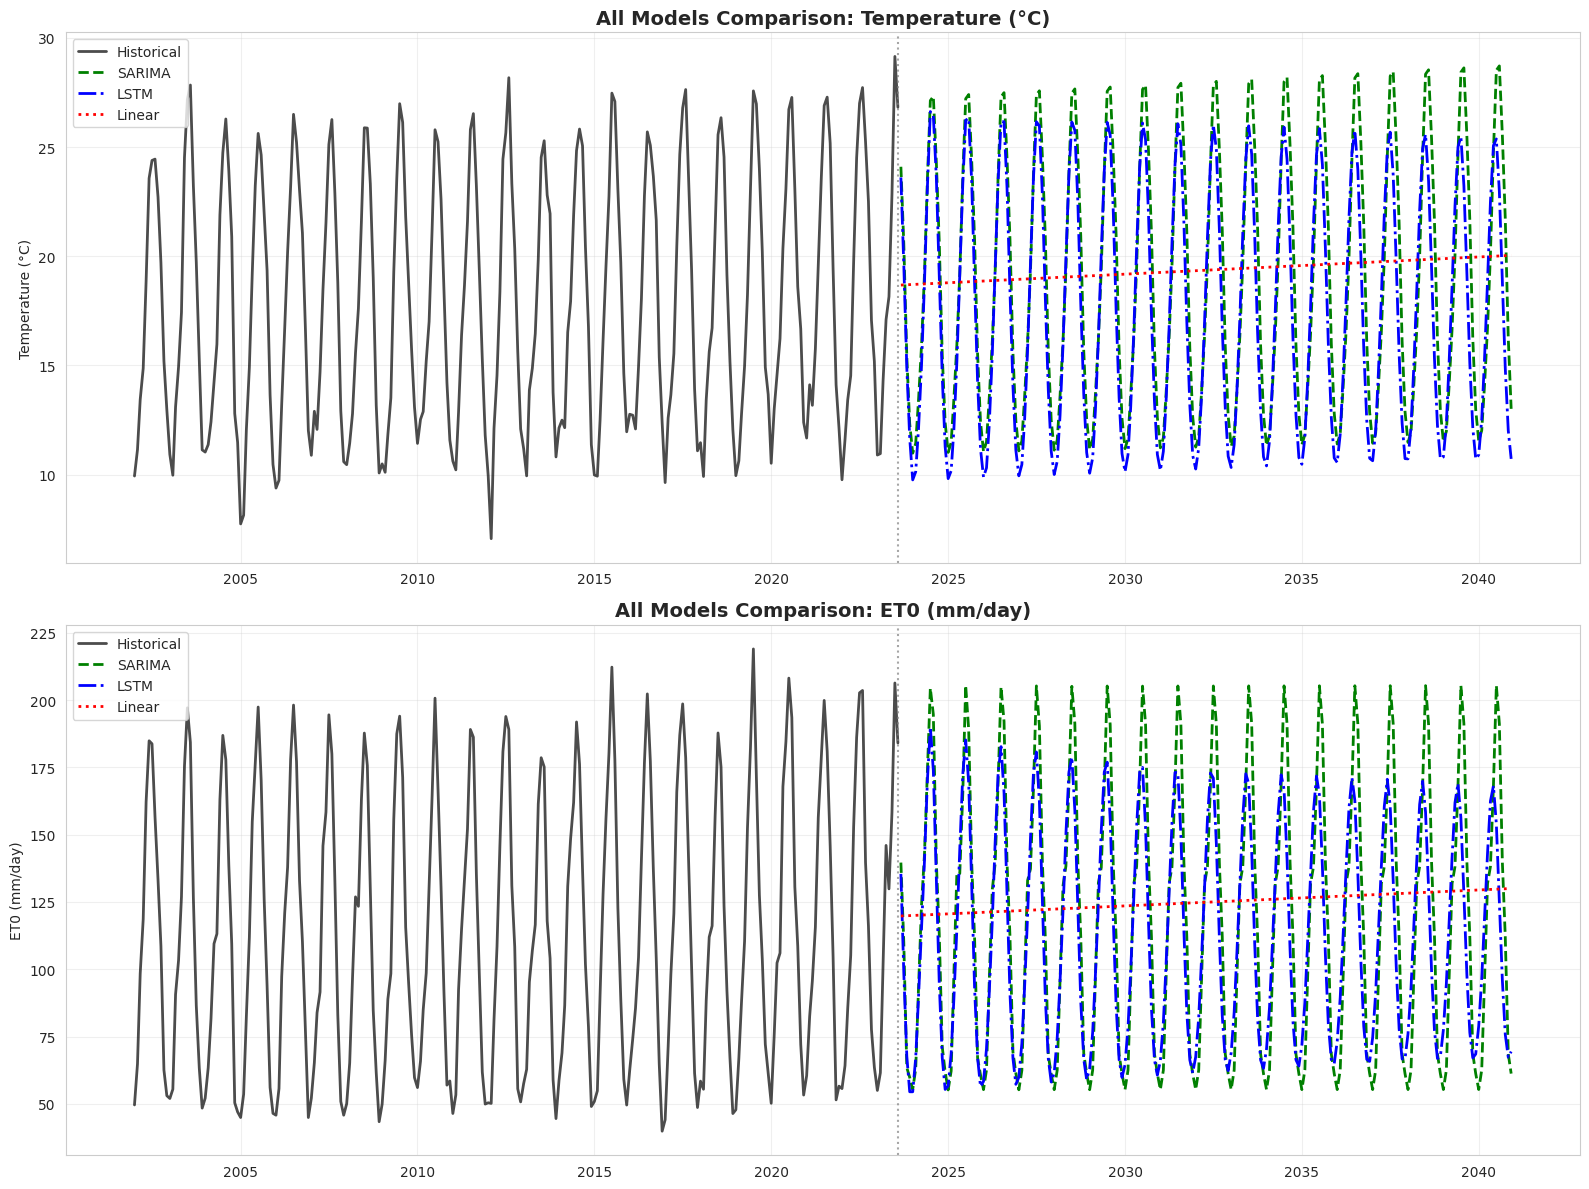

✅ Unified comparison visualization saved


In [16]:
# Compare all models for both variables
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

for idx, (var_name, var_config) in enumerate(VARIABLES.items()):
    col = var_config['column']

    # Historical
    axes[idx].plot(df.index, df[col],
                   label='Historical', color='black', linewidth=2, alpha=0.7)

    # SARIMA
    sarima_fc = sarima_results[var_name]['forecast']
    axes[idx].plot(sarima_fc['date'], sarima_fc['forecast'],
                   label='SARIMA', color='green', linewidth=2, linestyle='--')

    # LSTM (if available)
    if lstm_results:
        lstm_fc = lstm_results[var_name]['forecast']
        axes[idx].plot(lstm_fc['date'], lstm_fc['forecast'],
                       label='LSTM', color='blue', linewidth=2, linestyle='-.')

    # Linear
    linear_fc = linear_results[var_name]['forecast']
    axes[idx].plot(linear_fc['date'], linear_fc['forecast'],
                   label='Linear', color='red', linewidth=2, linestyle=':')

    axes[idx].set_title(f"All Models Comparison: {var_config['label']}",
                       fontsize=14, fontweight='bold')
    axes[idx].set_ylabel(var_config['label'])
    axes[idx].legend(loc='upper left', fontsize=10)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].axvline(x=df.index[-1], color='gray', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/unified_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Unified comparison visualization saved")

## 8. Save Forecasts

In [17]:
# Save forecasts for each model and variable
import os
os.makedirs(PREDICTIONS_DIR, exist_ok=True)

for var_name in VARIABLES.keys():
    # SARIMA
    sarima_df = sarima_results[var_name]['forecast'][['date', 'forecast']]
    sarima_df.to_csv(f'{PREDICTIONS_DIR}/sarima_{var_name}_forecast_2040.csv', index=False)

    # LSTM (if available)
    if lstm_results:
        lstm_df = lstm_results[var_name]['forecast']
        lstm_df.to_csv(f'{PREDICTIONS_DIR}/lstm_{var_name}_forecast_2040.csv', index=False)

    # Linear
    linear_df = linear_results[var_name]['forecast']
    linear_df.to_csv(f'{PREDICTIONS_DIR}/linear_{var_name}_forecast_2040.csv', index=False)

    print(f"✅ Saved all forecasts for {var_name}")

print("\n✅ All forecast files saved to Predictions/")

# Download files if in Colab
if IN_COLAB:
    print("\n📥 To download forecasts, run the cell below:")

✅ Saved all forecasts for temperature
✅ Saved all forecasts for et0

✅ All forecast files saved to Predictions/

📥 To download forecasts, run the cell below:


In [18]:
# Download results in Colab
if IN_COLAB:
    !zip -r forecasts.zip Predictions/ Results/
    from google.colab import files
    files.download('forecasts.zip')
    print("✅ Download started! Check your browser downloads.")

  adding: Predictions/ (stored 0%)
  adding: Predictions/lstm_et0_forecast_2040.csv (deflated 65%)
  adding: Predictions/linear_et0_forecast_2040.csv (deflated 61%)
  adding: Predictions/sarima_temperature_forecast_2040.csv (deflated 61%)
  adding: Predictions/lstm_temperature_forecast_2040.csv (deflated 68%)
  adding: Predictions/sarima_et0_forecast_2040.csv (deflated 61%)
  adding: Predictions/linear_temperature_forecast_2040.csv (deflated 62%)
  adding: Results/ (stored 0%)
  adding: Results/sarima_unified_forecast.png (deflated 2%)
  adding: Results/historical_comparison.png (deflated 3%)
  adding: Results/unified_model_comparison.png (deflated 3%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started! Check your browser downloads.


## 9. Summary & Model Performance

In [19]:
# Summary report
print("\n" + "="*70)
print("UNIFIED FORECASTING SUMMARY")
print("="*70)

for var_name, var_config in VARIABLES.items():
    print(f"\n📊 **{var_config['label']}**")
    print("-" * 70)

    # Forecast range
    print(f"\nForecast Period: {df.index[-1].date()} → {FORECAST_END}")
    print(f"Total months forecasted: {len(sarima_results[var_name]['forecast'])}")

    # Model parameters
    print(f"\n**SARIMA Configuration:**")
    print(f"  Order: {sarima_results[var_name]['order']}")
    print(f"  Seasonal: {sarima_results[var_name]['seasonal_order']}")

    print(f"\n**Linear Regression:**")
    print(f"  Slope: {linear_results[var_name]['slope']:.6f}")
    print(f"  R²: {linear_results[var_name]['r2']:.4f}")

    # Forecast statistics
    sarima_mean = sarima_results[var_name]['forecast']['forecast'].mean()
    linear_mean = linear_results[var_name]['forecast']['forecast'].mean()

    print(f"\n**Forecast Means (2024-2040):**")
    print(f"  SARIMA: {sarima_mean:.2f}")
    if lstm_results:
        lstm_mean = lstm_results[var_name]['forecast']['forecast'].mean()
        print(f"  LSTM: {lstm_mean:.2f}")
    print(f"  Linear: {linear_mean:.2f}")

print("\n" + "="*70)
print("✅ Unified forecasting complete!")
print("="*70)


UNIFIED FORECASTING SUMMARY

📊 **Temperature (°C)**
----------------------------------------------------------------------

Forecast Period: 2023-08-01 → 2040-12-01
Total months forecasted: 208

**SARIMA Configuration:**
  Order: (1, 0, 0)
  Seasonal: (1, 0, 1, 12)

**Linear Regression:**
  Slope: 0.006564
  R²: 0.0074

**Forecast Means (2024-2040):**
  SARIMA: 18.93
  LSTM: 17.50
  Linear: 19.36

📊 **ET0 (mm/day)**
----------------------------------------------------------------------

Forecast Period: 2023-08-01 → 2040-12-01
Total months forecasted: 208

**SARIMA Configuration:**
  Order: (0, 0, 1)
  Seasonal: (2, 0, 0, 12)

**Linear Regression:**
  Slope: 0.049369
  R²: 0.0054

**Forecast Means (2024-2040):**
  SARIMA: 118.69
  LSTM: 112.28
  Linear: 124.89

✅ Unified forecasting complete!
